# **Churn Analysis**

### **Project Overview & Business Goals**

The objective of this project is to understand the key drivers of customer churn and identify early warning signals that the business can use to proactively retain users. Customer churn represents a direct loss of recurring revenue, and identifying leading indicators of churn enables earlier and more cost-effective interventions.

The business goals are to:

- Identify behavioral and service-related factors associated with churn
- Develop actionable metrics that can be monitored regularly
- Provide clear, data-driven recommendations to reduce churn and improve retention

To achieve this, account information, user activity data, and customer support data were integrated to form a comprehensive view of customer behavior.

In [2]:
# Change the working directory
import os
os.chdir("C:/Users/Tarek/OneDrive/Documents/data_camp_python/data")

### **Importing Modules and Reading Data**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Read the data
account_info = pd.read_csv("da_fitly_account_info.csv")
customer_support = pd.read_csv("da_fitly_customer_support.csv")
user_activity = pd.read_csv("da_fitly_user_activity.csv")

### **Data Validation and Cleaning**

The 3 datasets include the following features and target variable (churn_status):

- **customer_id**: Rename the customer_id column as user_id in the account_info dataframe to match the naming with the other datasets. Remove the letter 'C' and convert the variable to integer. There are 400 customers/users with unique ids.
- **email**: There are 400 unique emails, one for each user in the account_info data set.
- **state**: There are 50 unique states. No missing or inconsistent values.
- **Plan**: There are 4 types of plans('Enterprise', 'Basic', 'Free', 'Pro'). This matches what is expected. 
- **plan_list_price**: The list prices range between 0 (free plan) and 148 (Enterprise). Grouping data by plan, the average price for each plan was estimated. 0 for free as expected, about 20 for basic, 54 for pro, and 148 for enterprise. These categories are as anticipated.
- **churn_status**: There are 1 unique value ('Y'), and nan, meaning missing. I assumed that for missing values (nan) that the customer did not drop (no churn). I developed a new integer variable, 'churn', where Y is mapped to 1 and nan by 0. This is the churn target variable. churn_status in the analysis below is created and labeled as Retained (churn = 0) or Churned (churn = 1).
- **ticket_time**: The datatype of the variable is an object. So I converted it to datetime. No duplicated records for users based on user_id.
- **user_id** in the customer_support data: There are 367 unique users. However, the number of records is 918. So many users created multiple tickets.
- **channel**: In the customer_support dataset, there were 4 types of channels (-, chat, email, phone). Since there are only 39 (~4%)records with channel of -, I removed these records from csutomer_support dataset, and left with 3 channels (chat, email, phone) as expected, and a total of 879 records (chat: 294, email: 298, phone: 287).
- **topic**: There are 4 types of topics (technical, account, billing, and other).
- **resolution_time_hours**: It ranges from about 0.52 to 32.46 hours, with mean of about 10.3 hours and median 9 hours. No missing values.
- **state**: Values are either 0 or 1. No missing values.
- **comments**: Feedback from customers about their experience. I didn't include the variable in the analysis. 
- **event_time**: Similar to ticket_time.
- **user_id** in the user_activity dataset: There are 246 unique ids. Total number of records is 445. So multiple customers made multiple activities.
- **event_type**: There are 4 types of events ('watch_video', 'share_workout', 'read_article', 'track_workout'). 

In [6]:
# rename customer_id to user_id in the account_info dataframe
account_info = account_info.rename(columns={"customer_id": "user_id"})

# Remove C from the id, and convert it to an integer
account_info["user_id"] = (
    account_info["user_id"]
      .str.lstrip("C")   # remove leading 'C'
      .astype(int)       # convert to integer
)
account_info.head(2)

,user_id,email,state,plan,plan_list_price,churn_status
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y
1,10001,user10001@example.net,Louisiana,Basic,22,Y


In [7]:
# Create a churn variable based on churn_status
account_info["churn"] = np.where(account_info["churn_status"] == "Y", 1, 0)
account_info.head()

,user_id,email,state,plan,plan_list_price,churn_status,churn
0,10000,user10000@example.com,New Jersey,Enterprise,105,Y,1
1,10001,user10001@example.net,Louisiana,Basic,22,Y,1
2,10002,user10002@example.net,Oklahoma,Basic,24,NaN,0
3,10003,user10003@example.com,Michigan,Free,0,NaN,0
4,10004,user10004@example.com,Texas,Enterprise,119,NaN,0


In [8]:
account_info_cleaned = account_info.drop(columns=["churn_status", "email"])
account_info_cleaned.head()

,user_id,state,plan,plan_list_price,churn
0,10000,New Jersey,Enterprise,105,1
1,10001,Louisiana,Basic,22,1
2,10002,Oklahoma,Basic,24,0
3,10003,Michigan,Free,0,0
4,10004,Texas,Enterprise,119,0


In [9]:
customer_support['channel'].unique()

array(['chat', 'phone', '-', 'email'], dtype=object)

In [10]:
# Exclude records with a -
customer_support_sub = customer_support[customer_support['channel'] != '-']
len(customer_support_sub)

879

In [11]:
# Drop state and comments columns
customer_support_cleaned = customer_support_sub.drop(columns=['state', 'comments'])
customer_support_cleaned.columns

Index(['ticket_time', 'user_id', 'channel', 'topic', 'resolution_time_hours'], dtype='object')

In [12]:
# Ensure that ticket_time is a formatted date
customer_support_cleaned["ticket_time"] = pd.to_datetime(customer_support_cleaned["ticket_time"])
user_activity["event_time"] = pd.to_datetime(user_activity["event_time"])
user_activity_cleaned = user_activity

In [13]:
# Number of records in each dataframe
print('Number of records in the acoount_info dataframe:', len(account_info_cleaned))
print('Number of records in the customer_support dataframe:', len(customer_support_cleaned))
print('Number of records in the user_activity dataframe:', len(user_activity_cleaned))

Number of records in the acoount_info dataframe: 400
Number of records in the customer_support dataframe: 879
Number of records in the user_activity dataframe: 445


## **Processing and Preparing Data for Analysis**

In [14]:
# Aggregate data by user_id, and calculate the total number of events, the number of active days, 
# and the last activity the user has made
activity_time_features = (
    user_activity
    .groupby('user_id')
    .agg(
        total_events=('event_time', 'count'),
        active_days=('event_time', lambda x: x.dt.date.nunique()),
        last_activity=('event_time', 'max')
    )
    .reset_index()
)

# Use the last activity day in the data as a reference
reference_date = user_activity_cleaned["event_time"].max()
# Calculate the number of days since last activity
activity_time_features["days_since_last_activity"] = (
    reference_date - activity_time_features["last_activity"]
).dt.days

In [ ]:
# Restructure the data to have one column for each of the event type. 
# This restructuring would be helpful when bulding a predictive model, and/or when combining event_type with channel
activity_event_flags = (
    user_activity
    .assign(value=1)
    .pivot_table(
        index='user_id',
        columns='event_type',
        values='value',
        aggfunc='max',
        fill_value=0
    )
)

activity_event_flags.head()

event_type,read_article,share_workout,track_workout,watch_video
user_id,,,,
10000,1,0,0,1
10001,1,0,0,0
10002,1,0,0,0
10003,0,0,1,0
10004,0,0,1,1


In [16]:
user_activity_df = activity_time_features.merge(activity_event_flags, on="user_id")
user_activity_df.head()

,user_id,total_events,active_days,last_activity,days_since_last_activity,read_article,share_workout,track_workout,watch_video
0,10000,3,3,2025-11-13 00:14:10.471225,18,1,0,0,1
1,10001,1,1,2025-06-22 06:40:26.706374,162,1,0,0,0
2,10002,1,1,2025-09-17 17:33:50.117062,75,1,0,0,0
3,10003,1,1,2025-09-15 10:21:59.595794,77,0,0,1,0
4,10004,4,4,2025-10-11 05:17:36.302142,51,0,0,1,1


In [ ]:
# Are there any duplicates using user_id and ticket_time?
customer_support_cleaned.duplicated(subset=['user_id', 'ticket_time']).any()

np.False_

In [ ]:
# Aggregating and calculating number of tickets each customer has made, and the average resolution time that 
# each customer has experienced
support_time_features = (
    customer_support_cleaned
    .groupby("user_id")
    .agg(
        tickets_count=("ticket_time", "count"),
        avg_resolution_hours=("resolution_time_hours", "mean")
    )
    .reset_index()
)
support_time_features.head()

,user_id,tickets_count,avg_resolution_hours
0,10000,3,21.446667
1,10001,4,17.542500
2,10002,3,6.433333
3,10004,3,8.556667
4,10005,2,7.815000


In [ ]:
# Similar to event_type logic
support_channel_flags = (
    customer_support_cleaned
    .assign(value=1)
    .pivot_table(
        index='user_id',
        columns='channel',
        values='value',
        aggfunc='max',
        fill_value=0
    )
)
support_channel_flags.head()

channel,chat,email,phone
user_id,,,
10000,1,1,0
10001,0,1,1
10002,1,1,0
10004,1,1,1
10005,1,0,1


In [ ]:
# Customer support dataframe
customer_support_df = support_time_features.merge(support_channel_flags, on="user_id")
customer_support_df.head()

,user_id,tickets_count,avg_resolution_hours,chat,email,phone
0,10000,3,21.446667,1,1,0
1,10001,4,17.542500,0,1,1
2,10002,3,6.433333,1,1,0
3,10004,3,8.556667,1,1,1
4,10005,2,7.815000,1,0,1


In [21]:
support_channel_counts = (
    customer_support_cleaned
    .groupby(['user_id', 'channel'])
    .size()
    .unstack(fill_value=0)
)
support_channel_counts.head()

channel,chat,email,phone
user_id,,,
10000,1,2,0
10001,0,1,3
10002,2,1,0
10004,1,1,1
10005,1,0,1


In [22]:
support_channel_share = (
    support_channel_counts
    .div(support_channel_counts.sum(axis=1), axis=0)
    .round(2)
    .fillna(0)
)
support_channel_share.head()

channel,chat,email,phone
user_id,,,
10000,0.33,0.67,0.00
10001,0.00,0.25,0.75
10002,0.67,0.33,0.00
10004,0.33,0.33,0.33
10005,0.50,0.00,0.50


In [133]:
# Merge the aggregated data with the account_info data. This is the master dataset, used in te anslysis.
# Fill missing values with 0. 
df_final = (
    account_info_cleaned
    .merge(user_activity_df, on='user_id', how='left')
    .merge(customer_support_df, on='user_id', how='left')
    .fillna(0)
)
len(df_final)

400

In [ ]:
# Add a churn_status feature. Retained is mapped to 0 and Churned is mapped to 1, using the churn feature
df_final['churn_status'] = df_final['churn'].map({
    0: 'Retained',
    1: 'Churned'
})
df_final.head()

,user_id,state,plan,plan_list_price,churn,total_events,active_days,last_activity,days_since_last_activity,read_article,share_workout,track_workout,watch_video,tickets_count,avg_resolution_hours,chat,email,phone,churn_status
0,10000,New Jersey,Enterprise,105,1,3.0,3.0,2025-11-13 00:14:10.471225,18.0,1.0,0.0,0.0,1.0,3.0,21.446667,1.0,1.0,0.0,Churned
1,10001,Louisiana,Basic,22,1,1.0,1.0,2025-06-22 06:40:26.706374,162.0,1.0,0.0,0.0,0.0,4.0,17.542500,0.0,1.0,1.0,Churned
2,10002,Oklahoma,Basic,24,0,1.0,1.0,2025-09-17 17:33:50.117062,75.0,1.0,0.0,0.0,0.0,3.0,6.433333,1.0,1.0,0.0,Retained
3,10003,Michigan,Free,0,0,1.0,1.0,2025-09-15 10:21:59.595794,77.0,0.0,0.0,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,Retained
4,10004,Texas,Enterprise,119,0,4.0,4.0,2025-10-11 05:17:36.302142,51.0,0.0,0.0,1.0,1.0,3.0,8.556667,1.0,1.0,1.0,Retained


In [25]:
# Estimate churn date for churned users assuming that the last actvity date was the date to churn
df_final['estimated_churn_date'] = df_final['last_activity']
df_final.loc[df_final['churn'] == 0, 'estimated_churn_date'] = pd.NaT

In [28]:
# Revenue loss due to churn
revenue_at_risk = df_final.loc[
    df_final['churn']==1, 'plan_list_price'
    ].sum()

# Overall churn rate
churn_rate = round(df_final['churn'].mean() * 100, 1)

# Churn rate by plan and by state
churn_by_plan = df_final.groupby('plan')['churn'].mean() * 100
churn_by_state = df_final.groupby('state')['churn'].mean() * 100

# Average engagement metrics
avg_days_inactive = df_final['days_since_last_activity'].mean().round(1)
avg_events_per_user = df_final['total_events'].mean().round(1)
avg_tickets_per_user = df_final['tickets_count'].mean().round(1)
avg_resolution_time = df_final['avg_resolution_hours'].mean().round(1)

In [29]:
# ---------------------------
# High-Risk Users (Churn Risk Score)
# ---------------------------
# Normalize features for scoring
df_final['days_inactive_norm'] = df_final['days_since_last_activity']/df_final['days_since_last_activity'].max()
df_final['tickets_norm'] = df_final['tickets_count']/df_final['tickets_count'].max()
df_final['events_norm'] = 1 - (df_final['total_events']/df_final['total_events'].max())  # more events -> lower risk

# Weighted churn risk score (0-1)
df_final['churn_risk_score'] = 0.5*df_final['days_inactive_norm'] + 0.3*df_final['tickets_norm'] + 0.2*df_final['events_norm']

# Flag high-risk users (top 20% risk)
risk_threshold = df_final['churn_risk_score'].quantile(0.8)
df_final['high_risk_user'] = df_final['churn_risk_score'] >= risk_threshold

In [30]:
print("\nTop 10 High-Risk Users:")
df_final[
    [
        'user_id','churn_status','days_since_last_activity','total_events','tickets_count','churn_risk_score','high_risk_user']
        ].sort_values(by='churn_risk_score', ascending=False).head(10)


Top 10 High-Risk Users:


,user_id,churn_status,days_since_last_activity,total_events,tickets_count,churn_risk_score,high_risk_user
191,10191,Retained,179.0,1.0,4.0,0.810000,True
119,10119,Churned,178.0,1.0,4.0,0.807207,True
1,10001,Churned,162.0,1.0,4.0,0.762514,True
187,10187,Churned,163.0,1.0,3.0,0.727807,True
180,10180,Retained,176.0,1.0,2.0,0.726620,True
230,10230,Retained,172.0,1.0,2.0,0.715447,True
168,10168,Retained,159.0,2.0,4.0,0.714134,True
144,10144,Retained,158.0,1.0,3.0,0.713841,True
36,10036,Churned,178.0,1.0,1.0,0.694707,True
39,10039,Retained,163.0,2.0,3.0,0.687807,True


### **Baseline Key Performance Indicators (KPIs)**

In [31]:
# ----------------------------------------------------------
# Baseline KPIs (Core Churn & Engagement Metrics (Baseline))
# ----------------------------------------------------------
baseline_metrics = {
    "Overall Churn Rate (%)": churn_rate,
    "Revenue at Risk ($)": revenue_at_risk,
    "Avg Days Since Last Activity": df_final['days_since_last_activity'].mean(),
    "Avg Number of Events per User": df_final['total_events'].mean(),
    "Avg Number of Tickets per User": df_final['tickets_count'].mean(),
    "Avg Resolution Time (hrs)": df_final['avg_resolution_hours'].mean()
}

print("=== Baseline Metrics ===")
for k,v in baseline_metrics.items():
    print(f"{k}: {v:.2f}")

print("\n=== Churn Rate by Plan (%) ===")
print(churn_by_plan)

=== Baseline Metrics ===
Overall Churn Rate (%): 28.50
Revenue at Risk ($): 4409.00
Avg Days Since Last Activity: 40.30
Avg Number of Events per User: 1.11
Avg Number of Tickets per User: 2.20
Avg Resolution Time (hrs): 9.26

=== Churn Rate by Plan (%) ===
plan
Basic         23.728814
Enterprise    26.086957
Free          40.952381
Pro           22.352941
Name: churn, dtype: float64


## **Exploring Data**

### 1. Distribution of Customers by Type of Event

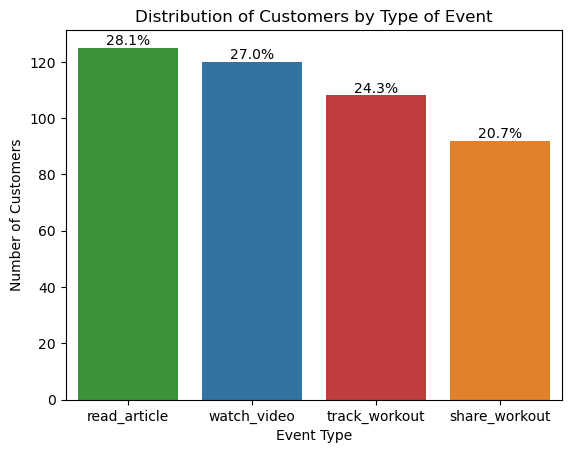

In [32]:
order = user_activity['event_type'].value_counts().index
ax = sns.countplot(data=user_activity, x="event_type", hue="event_type", order=order)

total = len(user_activity)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom'
    )

plt.title("Distribution of Customers by Type of Event")
plt.xlabel("Event Type")
plt.ylabel("Number of Customers")
plt.show()

### 2. Churn vs. Retention Rate

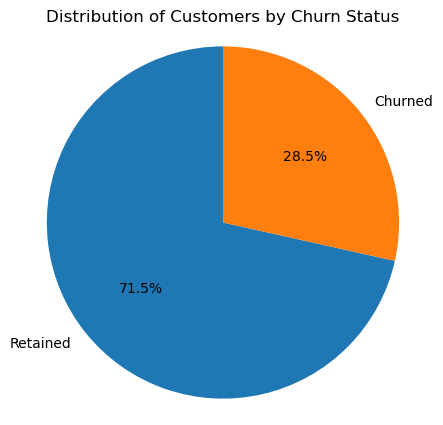

In [33]:
counts = df_final['churn_status'].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    startangle=90
)
plt.axis('equal')
plt.title('Distribution of Customers by Churn Status')

plt.show()

### 3. Distribution of Average Resolution Time Grouped by Churn Status

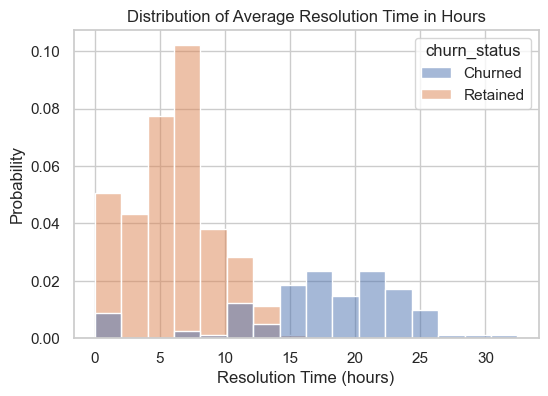

In [97]:
plt.figure(figsize=(6, 4))

sns.histplot(data=df_final, x="avg_resolution_hours", hue="churn_status", stat='density')
plt.title("Distribution of Average Resolution Time in Hours")
plt.xlabel("Resolution Time (hours)")
plt.ylabel("Probability")
plt.show()

### 4. Distribution of Resolution Time Grouped by Plan

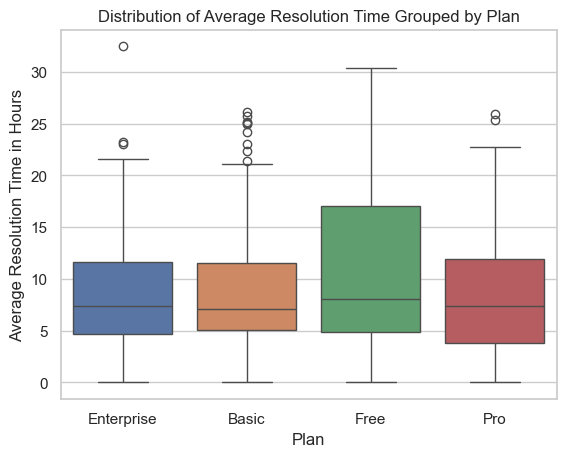

In [134]:
sns.boxplot(
    data=df_final,
    x="plan",
    y="avg_resolution_hours",
    hue="plan"
)

plt.title("Distribution of Average Resolution Time Grouped by Plan")
plt.ylabel("Average Resolution Time in Hours")
plt.xlabel("Plan")

plt.show()

For users with free subscription plan, average support resolution time is more spread than for users in the other tier plans. Basic Subscription plan has the lowest median support resolution time of about 7.4 hours. However, Free subscription plan has the largest median of 9 hours. On the other hand, the overall average is estimated to be about 10.2 hours. Data are right skewed with outliers included with the basic and enterprise plans.

### 5. Churn Rate by Plan

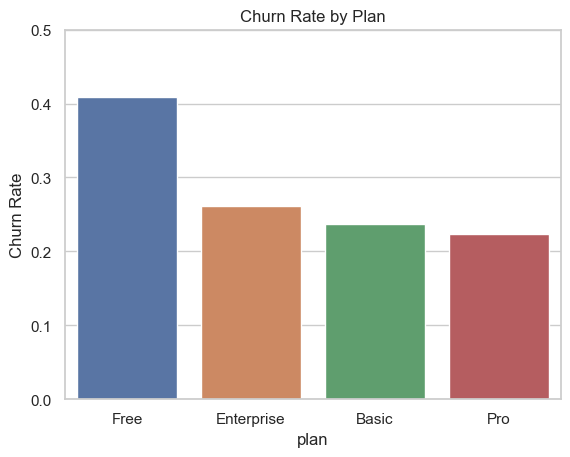

In [129]:
summary = (
    df_final.groupby('plan')
    .agg(
        churn_rate = ("churn", "mean"),
        users = ("churn", "count")
    )
    .reset_index()
    .sort_values(by='churn_rate', ascending=False)
)

ax = sns.barplot(
    data=summary,
    x='plan',
    y='churn_rate',
    hue='plan'
)

'''for bar, row in zip(ax.patches, summary.itertuples()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{row.churn_rate:.1%}",
        ha="center",
        va="bottom",
        fontsize=9
    )'''

plt.ylabel('Churn Rate')
plt.title('Churn Rate by Plan')
plt.ylim(0, 0.5)

plt.show()

Users with free plans exhibit the highest churn rate, indicating potential challenges in early value realization or onboarding.

### 6. Support Resolution Time Grouped by Plan and Churn Status

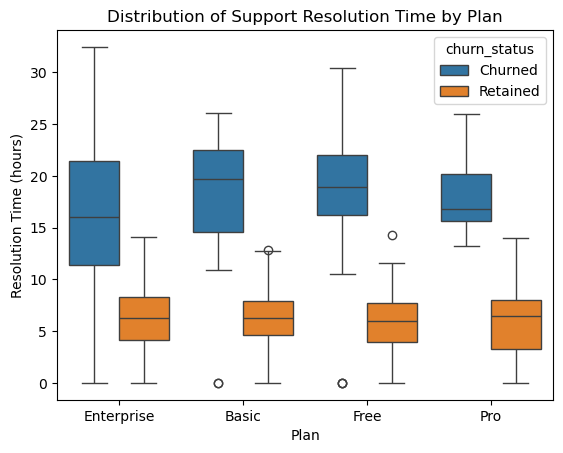

In [39]:
sns.boxplot(
    data=df_final,
    x="plan",
    y="avg_resolution_hours",
    hue="churn_status"
)

plt.xlabel("Plan")
plt.ylabel("Resolution Time (hours)")
plt.title("Distribution of Support Resolution Time by Plan")

plt.show()

Support resolution time varies by subscription plan. Within the same plan, churned users consistently experience longer resolution times than retained users, suggesting that support responsiveness may be associated with higher churn risk.

### 7. Engagement and Days Since Last Activity Analysis

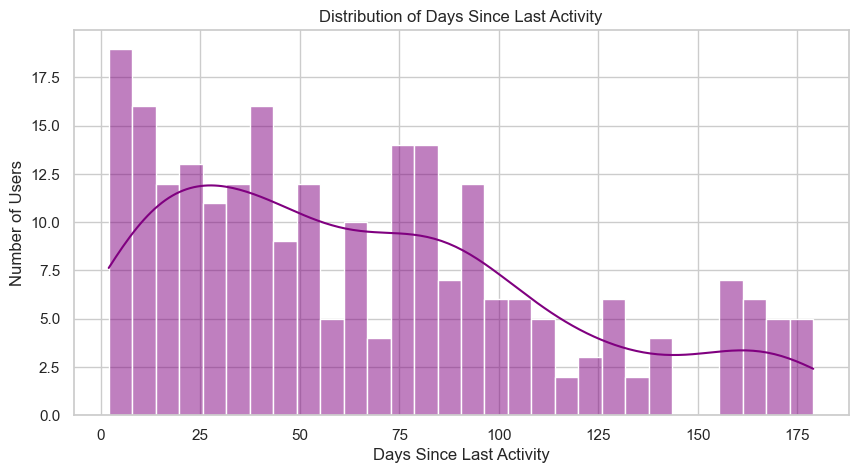

In [73]:
# Set Seaborn style
sns.set(style="whitegrid")

# ---------------------------
# 3. Distribution of Days Since Last Activity
# ---------------------------
plt.figure(figsize=(10,5))
sns.histplot(df_final[df_final['days_since_last_activity'] > 0]["days_since_last_activity"], bins=30, kde=True, color="purple")
plt.title("Distribution of Days Since Last Activity")
plt.xlabel("Days Since Last Activity")
plt.ylabel("Number of Users")
plt.show()

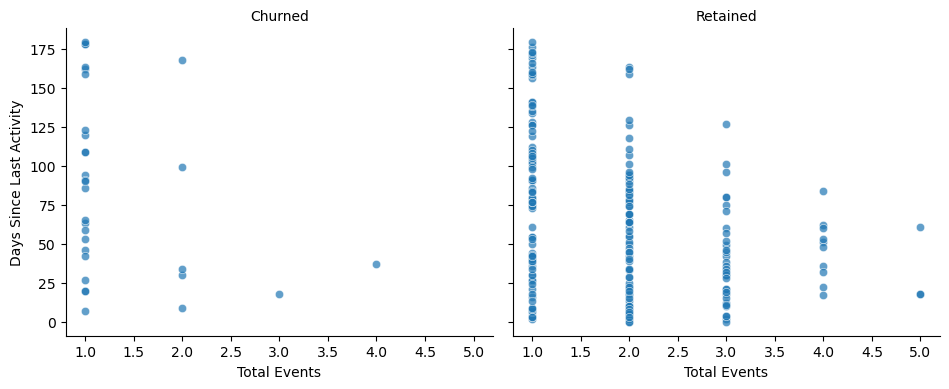

In [40]:
g = sns.FacetGrid(
    df_final[df_final["total_events"] != 0],
    col="churn_status",
    height=4,
    aspect=1.2
)

g.map_dataframe(
    sns.scatterplot,
    x="total_events",
    y="days_since_last_activity",
    alpha=0.7
)

g.set_axis_labels("Total Events", "Days Since Last Activity")
g.set_titles("{col_name}")
plt.show()

In [70]:
# Create bins and labels lists
bins = [0, 3, 7, 14, 30, 60, 179]
labels = [
    "0-3 days",
    "4-7 days",
    "8-14 days",
    "15-30 days",
    "31-60 days",
    "61+ days"
]

df_final["dsla_bucket"] = pd.cut(
    df_final["days_since_last_activity"],
    bins=bins,
    labels=labels,
    right=True,
    include_lowest=True
)

In [71]:
dsla_dist = (
    df_final["dsla_bucket"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dsla_dist.columns = ["DSLA Bucket", "User Count"]

dsla_dist["Percentage"] = (
    dsla_dist["User Count"] / dsla_dist["User Count"].sum() * 100
).round(1)

dsla_dist

,DSLA Bucket,User Count,Percentage
0,0-3 days,163,40.8
1,4-7 days,13,3.2
2,8-14 days,16,4.0
3,15-30 days,36,9.0
4,31-60 days,54,13.5
5,61+ days,118,29.5


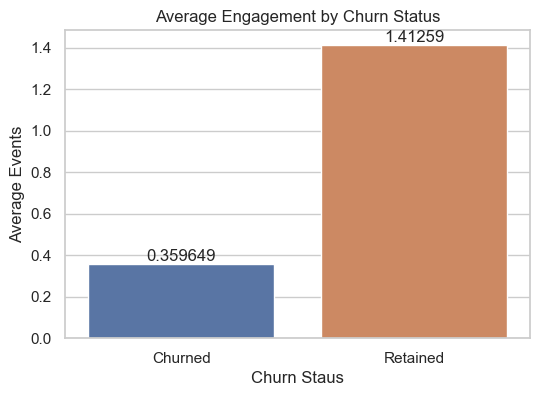

In [132]:
avg_events_by_churn_status = df_final.groupby("churn_status")["total_events"].mean()

plt.figure(figsize=(6, 4))
ax = sns.barplot(
    df_final, 
    x='churn_status', 
    y='total_events',
    hue="churn_status",
    errorbar=None)   # removes confidence intervals)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Average Engagement by Churn Status")
plt.xlabel("Churn Staus")
plt.ylabel("Average Events")
plt.show()

- This boxplot compares total user events between retained and churned users. Churned users are concentrated at lower activity levels, while retained users show higher and more dispersed engagement, indicating that sustained usage is associated with retention.
- Retained users exhibit a higher median activity level and greater variability, whereas churned users display consistently lower engagement. 

Churned users tend to have longer periods of inactivity, suggesting disengagement precedes churn.

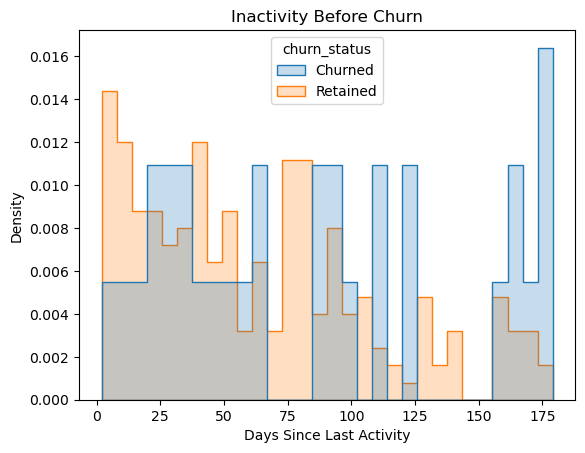

In [43]:
sns.histplot(
    data=df_final[df_final["days_since_last_activity"] > 0],
    x="days_since_last_activity",
    hue="churn_status",
    bins=30,
    stat="density",
    element="step",
    common_norm=False
)

plt.xlabel("Days Since Last Activity")
plt.ylabel("Density")
plt.title("Inactivity Before Churn")
plt.show()


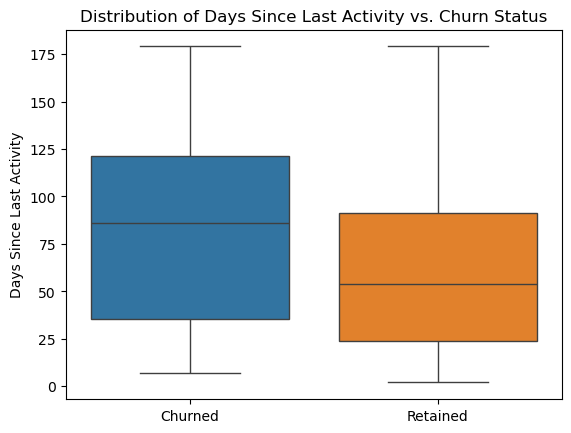

In [45]:
sns.boxplot(
    data=df_final[df_final["days_since_last_activity"] > 0],
    x="churn_status",
    y="days_since_last_activity",
    hue="churn_status"
)

plt.xlabel("")
plt.ylabel("Days Since Last Activity")
plt.title("Distribution of Days Since Last Activity vs. Churn Status")
plt.show()


In [46]:
df_final["activity_level"] = pd.cut(
    df_final[df_final["total_events"] > 0]["total_events"],
    bins=[0, 1, 2, 3, 5],
    labels=["Very_low", "Low", "Medium", "High"]
)
len(df_final[df_final["total_events"] != 0][["total_events", "activity_level"]])

246

In [123]:
churn_by_activity = (
    df_final[df_final["total_events"] != 0].groupby("activity_level", observed=True)
      .agg(
          churn_rate=("churn", "mean"),
          users=("activity_level", "count")
      )
      .reset_index()
)
churn_by_activity

,activity_level,churn_rate,users
0,Very_low,0.214286,112
1,Low,0.058140,86
2,Medium,0.029412,34
3,High,0.071429,14


In [117]:
churn_by_activity_plan = (
    df_final[df_final["total_events"] != 0].groupby(["activity_level", "plan"], observed=True)
      .agg(
          churn_rate=("churn", "mean")
      )
      .reset_index()
)

churn_by_activity_plan.sort_values(by="churn_rate", ascending=False).head()

,activity_level,plan,churn_rate
2,Very_low,Free,0.461538
12,High,Basic,0.250000
1,Very_low,Enterprise,0.173913
3,Very_low,Pro,0.153846
0,Very_low,Basic,0.108108


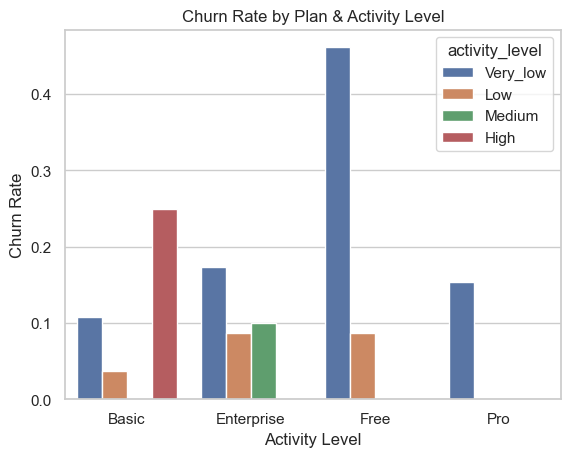

In [127]:
sns.barplot(
    data=churn_by_activity_plan,
    x="plan",
    y="churn_rate",
    hue="activity_level"
)

plt.title("Churn Rate by Plan & Activity Level")
plt.xlabel("Activity Level")
plt.ylabel("Churn Rate")
plt.show()

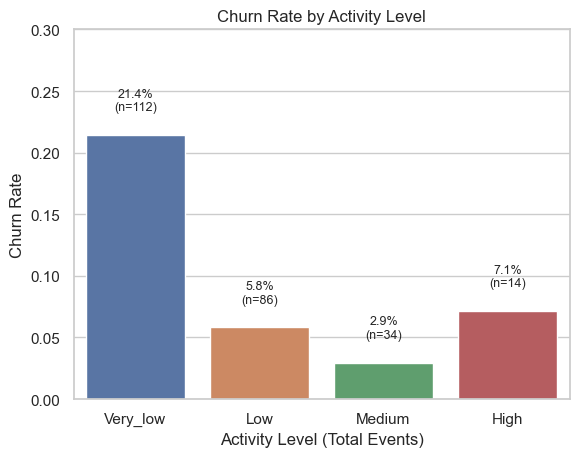

In [125]:
ax = sns.barplot(
    data=churn_by_activity,
    x="activity_level",
    y="churn_rate",
    hue="activity_level"
)

# Annotate with % and n
for i, row in churn_by_activity.iterrows():
    ax.text(
        i,
        row["churn_rate"] + 0.02,
        f"{row['churn_rate']:.1%}\n(n={row['users']})",
        ha="center",
        fontsize=9
    )

plt.xlabel("Activity Level (Total Events)")
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Activity Level")
plt.ylim(0, 0.3)

plt.show()

The bar chart reveals a strong inverse relationship between user activity and churn. Churn is highest among users in the lowest activity quartile—especially those with only one recorded event—and decreases sharply as activity increases. This indicates that even modest gains in early engagement are associated with substantially higher retention.

Implication: Establishing and optimizing an early engagement or activation threshold (e.g., ≥2–3 meaningful events) should be prioritized, as small increases in initial user activity may yield outsized retention gains.

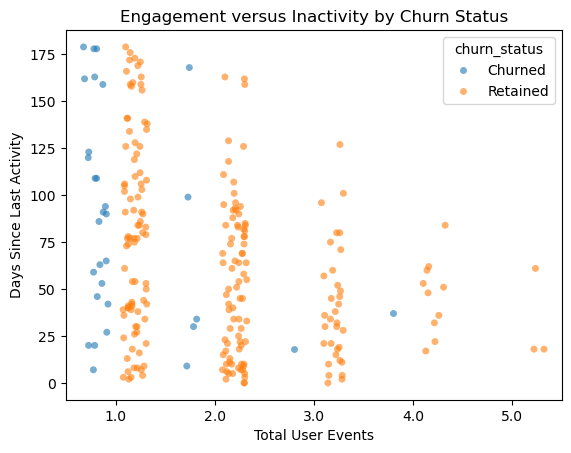

In [51]:
sns.stripplot(
    data=df_final[df_final["total_events"] != 0],
    x="total_events",
    y="days_since_last_activity",
    hue="churn_status",
    jitter=0.25,
    dodge=True,
    alpha=0.6
)

plt.xlabel("Total User Events")
plt.ylabel("Days Since Last Activity")
plt.title("Engagement versus Inactivity by Churn Status")

plt.show()

In [52]:
summary_df = (
    df_final[df_final["total_events"] > 0].groupby(["total_events", "churn_status"])["days_since_last_activity"]
    .mean()
    .reset_index()
)

In [53]:
summary_df

,total_events,churn_status,days_since_last_activity
0,1.0,Churned,93.458333
1,1.0,Retained,81.511364
2,2.0,Churned,68.000000
3,2.0,Retained,54.333333
4,3.0,Churned,18.000000
5,3.0,Retained,40.787879
6,4.0,Churned,37.000000
7,4.0,Retained,46.500000
8,5.0,Retained,32.333333


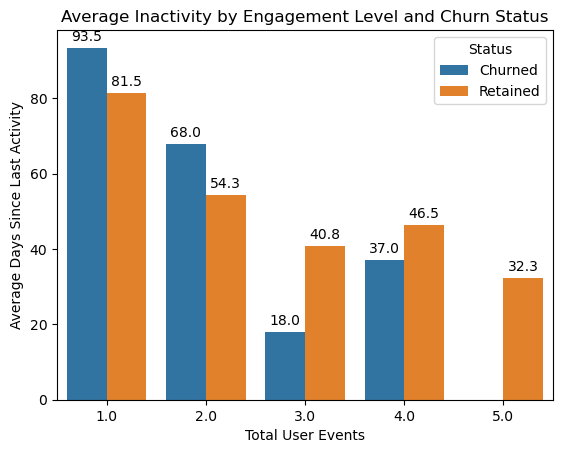

In [54]:
ax = sns.barplot(
    data=summary_df,
    x="total_events",
    y="days_since_last_activity",
    hue="churn_status"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.xlabel("Total User Events")
plt.ylabel("Average Days Since Last Activity")
plt.title("Average Inactivity by Engagement Level and Churn Status")
plt.legend(title="Status")

plt.show()

In [55]:
(df_final["days_since_last_activity"] >= 18).sum()

np.int64(203)

In [56]:
((df_final["churn"] == 0) & (df_final["total_events"] >= 1) & (df_final["days_since_last_activity"] <= 180)).sum()

np.int64(215)

This bar chart shows the mean number of days since last activity across engagement levels, split by churn status. Among low-engagement users (1 and 2 events), churned users exhibit substantially longer inactivity periods than retained users, indicating disengagement as a precursor to churn.

In [95]:
df_final[
    df_final[
        "days_since_last_activity"] > 0
        ].groupby('churn_status')["days_since_last_activity"].agg(['mean', 'median'])

,mean,median
churn_status,,
Churned,85.096774,86.0
Retained,63.594340,54.0


In [57]:
df_final["ticket_level"] = pd.cut(
    df_final["tickets_count"],
    bins=[0, 1, 2, 3, 6],
    labels=["Very low", "Low", "Medium", "High"]
)


In [58]:
churn_by_tickets = (
    df_final.groupby("ticket_level", observed=True)
      .agg(
          churn_rate=("churn", "mean"),
          users=("churn", "count")
      )
      .reset_index()
)

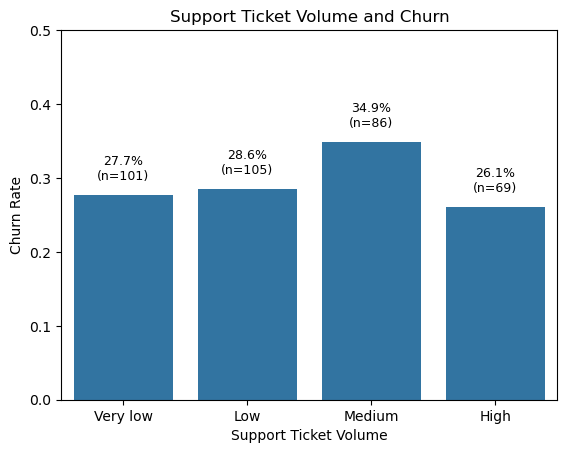

In [59]:
ax = sns.barplot(
    data=churn_by_tickets,
    x="ticket_level",
    y="churn_rate"
)

for i, row in churn_by_tickets.iterrows():
    ax.text(
        i,
        row["churn_rate"] + 0.02,
        f"{row['churn_rate']:.1%}\n(n={row['users']})",
        ha="center",
        fontsize=9
    )

plt.xlabel("Support Ticket Volume")
plt.ylabel("Churn Rate")
plt.title("Support Ticket Volume and Churn")
plt.ylim(0, 0.5)

plt.show()


Churn does not increase consistently with ticket volume, indicating that the number of support interactions alone is not a strong determinant of churn.

<Axes: xlabel='total_events', ylabel='days_since_last_activity'>

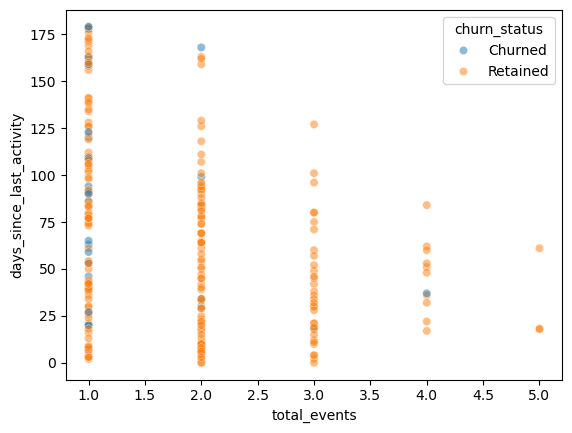

In [60]:
sns.scatterplot(
    data=df_final[df_final["total_events"] > 0],
    x="total_events",
    y="days_since_last_activity",
    hue="churn_status",
    alpha=0.5
)

- Churned users cluster at low activity and prolonged inactivity. 
- On the other hand, there is no clear linear relationship between support volume and churn.
- Users who churned are mostly concentrated among those with very low engagement and long periods of inactivity.
- Users who stayed tend to be more active and have used the service more recently
- Many churned users had not used the service for a long time before leaving.
- This makes long inactivity a strong signal that a user may be at risk of churn.
- Thus, re-engaging inactive users earlier could help reduce churn.
- Users who contacted support appear in both retained and churned groups.
- There is no clear pattern showing that more support tickets automatically lead to churn.
- It is **not the number of support interactions** that matters most, but likely **how quickly and effectively issues are resolved**.

Users are most likely to churn when they stop engaging and become inactive, while support usage by itself does not strongly predict whether someone will leave.

### 8. Event Type and Channel by Churn/Retention Analysis

In [61]:
# create event exposure at user level
event_exposure = (
    user_activity
    .assign(exposed=1)
    .pivot_table(
        index='user_id',
        columns='event_type',
        values='exposed',
        aggfunc='max',
        fill_value=0
    )
    .reset_index()
)

event_exposure.head()

event_type,user_id,read_article,share_workout,track_workout,watch_video
0,10000,1,0,0,1
1,10001,1,0,0,0
2,10002,1,0,0,0
3,10003,0,0,1,0
4,10004,0,0,1,1


In [62]:
# Merge with churn data
event_churn = (
    event_exposure
    .merge(df_final[['user_id', 'churn_status']], on='user_id')
    .melt(
        id_vars=['user_id', 'churn_status'],
        var_name='event_type',
        value_name='exposed'
    )
    .query('exposed == 1')
)


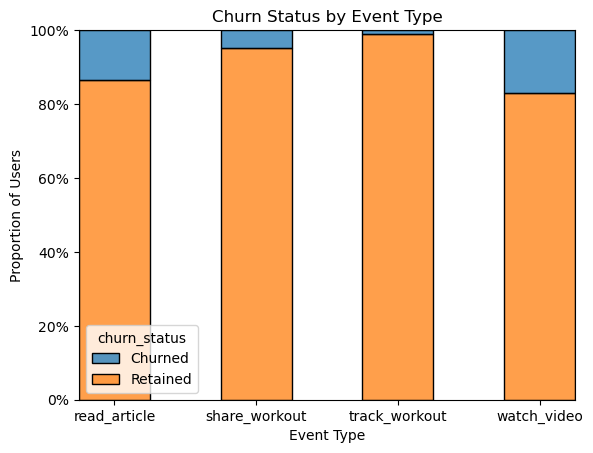

In [63]:

ax = sns.histplot(
    data=event_churn,
    x='event_type',
    hue='churn_status',
    multiple='fill',
    shrink=0.5
)

ax.set_ylabel('Proportion of Users')
ax.set_xlabel('Event Type')
ax.set_title('Churn Status by Event Type')
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')

plt.show()

In [64]:
event_channel_cols = [
    col for col in df_final.columns
    if col in ['read_article', 'share_workout', 'track_workout', 'watch_video', 'chat', 'email', 'phone']
]

# reshape df_final for visualization (wide to long using pd.melt)
df_long = (
    df_final
    .melt(
        id_vars=['user_id', 'churn_status', 'churn'],
        value_vars=event_channel_cols,
        var_name='event_type_channel',
        value_name='exposed'
    )
    .query('exposed == 1')
)

df_long.tail()

,user_id,churn_status,churn,event_type_channel,exposed
2789,10389,Retained,0,phone,1.0
2792,10392,Retained,0,phone,1.0
2793,10393,Retained,0,phone,1.0
2795,10395,Retained,0,phone,1.0
2797,10397,Churned,1,phone,1.0


In [65]:
df_long['retention'] = 1 - df_long['churn']

retention_by_event_channel = (
    df_long
    .groupby('event_type_channel')['retention']
    .mean()
    .sort_values()
    .reset_index()
)

retention_by_event_channel

,event_type_channel,retention
0,email,0.679070
1,phone,0.712871
2,chat,0.725490
3,watch_video,0.828571
4,read_article,0.865385
5,share_workout,0.950617
6,track_workout,0.989691


In [66]:
event_cols = ['track_workout', 'share_workout', 'read_article', 'watch_video']
channel_cols = ['chat', 'email', 'phone']

df_event_channel = []

for event in event_cols:
    for channel in channel_cols:
        temp = df_final[
            (df_final[event] == 1) & (df_final[channel] == 1)
        ][['user_id', 'churn_status', 'churn']].copy()

        temp['event_type'] = event
        temp['channel'] = channel

        df_event_channel.append(temp)

df_event_channel = pd.concat(df_event_channel, ignore_index=True)
df_event_channel.head()

,user_id,churn_status,churn,event_type,channel
0,10004,Retained,0,track_workout,chat
1,10009,Retained,0,track_workout,chat
2,10023,Retained,0,track_workout,chat
3,10029,Retained,0,track_workout,chat
4,10030,Retained,0,track_workout,chat


In [67]:
df_combined = df_event_channel.copy()

df_combined['event_channel'] = (
    df_combined['event_type'] + ' | ' + df_combined['channel']
)
df_combined.head()

,user_id,churn_status,churn,event_type,channel,event_channel
0,10004,Retained,0,track_workout,chat,track_workout | chat
1,10009,Retained,0,track_workout,chat,track_workout | chat
2,10023,Retained,0,track_workout,chat,track_workout | chat
3,10029,Retained,0,track_workout,chat,track_workout | chat
4,10030,Retained,0,track_workout,chat,track_workout | chat


In [68]:
df_combined['retention'] = 1 - df_combined['churn']

plot_df = (
    df_combined
    .groupby('event_channel')['retention']
    .agg(
        retention_rate = 'mean',
        n_users = 'count'
    )
    .sort_values(by='retention_rate', ascending=False)
    .reset_index()
)

# REMOVE combinations with no users
# plot_df = plot_df[plot_df['n_users'] >0 ].head(10)

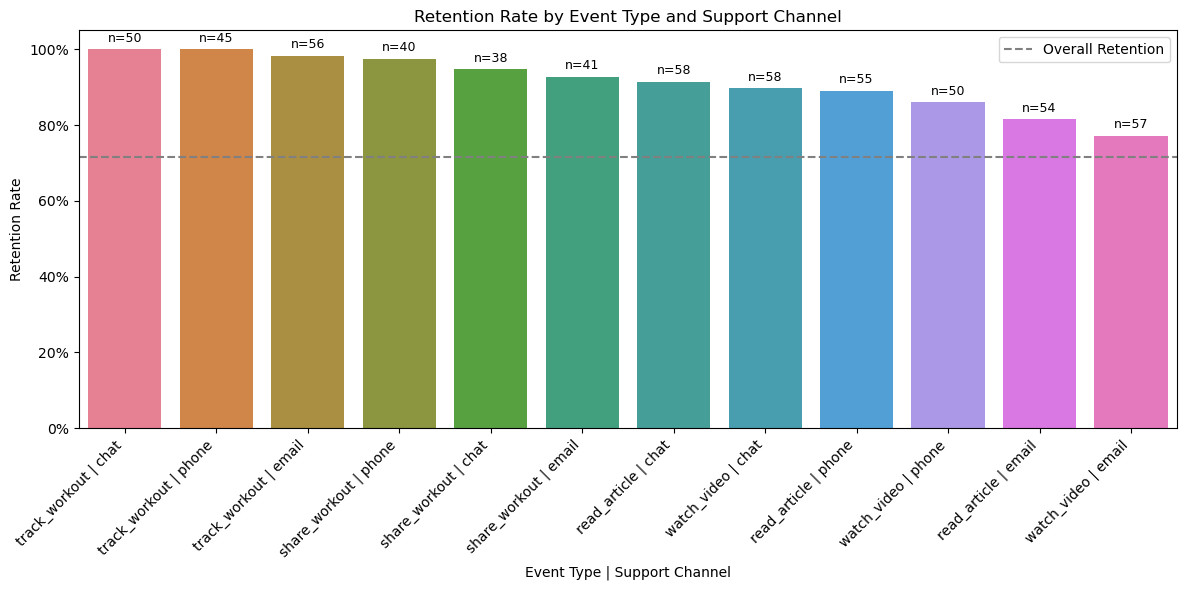

In [69]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    data=plot_df,
    x='event_channel',
    y='retention_rate',
    hue='event_channel'
)

ax.set_ylabel('Retention Rate')
ax.yaxis.set_major_formatter(lambda x, _: f'{x:.0%}')
ax.set_xlabel('Event Type | Support Channel')
ax.set_title('Retention Rate by Event Type and Support Channel')

plt.xticks(rotation=45, ha='right')

for i, row in plot_df.iterrows():
    ax.text(i, row['retention_rate'] + 0.02, f"n={row['n_users']}", ha='center', fontsize=9)

df_final['retention'] = 1 - df_final['churn']
# Add overall retention line
overall_retention = df_final['retention'].mean()
ax.axhline(overall_retention, linestyle='--', color='gray', label='Overall Retention')
plt.legend()
plt.tight_layout()
plt.show()

### 9. Revenue @ Risk

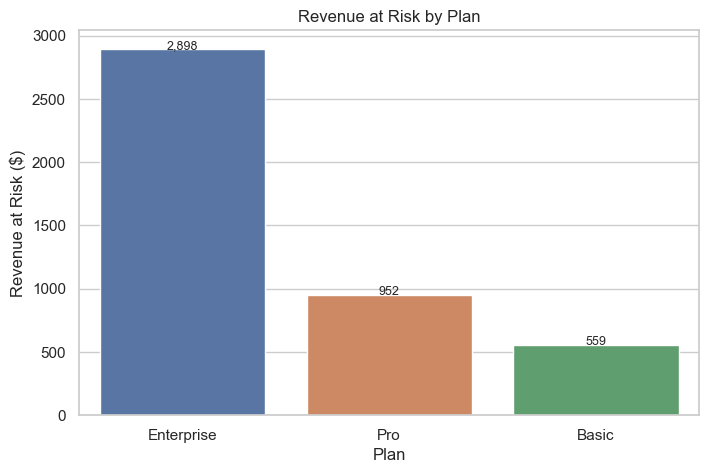

In [ ]:
sns.set(style="whitegrid")

# ---------------------------
# Revenue at Risk by Plan
# ---------------------------
revenue_loss = df_final[df_final['churn']==1].groupby('plan')['plan_list_price'].sum().sort_values(ascending=False)
filtered = revenue_loss[revenue_loss.index != "Free"]

plt.figure(figsize=(8,5))
ax = sns.barplot(
    x=filtered.index, 
    y=filtered.values, 
    hue=filtered.index)
plt.title("Revenue at Risk by Plan")
plt.ylabel("Revenue at Risk ($)")
plt.xlabel("Plan")

for i, value in enumerate(filtered):
    ax.text(
        i,
        value,
        f"{value:,.0f}",
        ha="center",
        fontsize=9
    )

plt.show()

## **Summary**

#### **Key Findings**
- Churn is primarily driven by disengagement. Users who churn are heavily concentrated among those with very low activity and long periods of inactivity.
- Inactivity is a strong early warning signal. The number of days since last activity increases markedly prior to churn, indicating that users often disengage well before formally leaving.
- Engagement protects against churn. Even modest increases in user activity and early activation are associated with significantly higher retention.
- Support volume alone does not predict churn. Users who contact support appear in both retained and churned groups, with no clear linear relationship between ticket volume and churn.
- Support quality matters more than quantity. Longer resolution times are more common among churned users within the same plan, suggesting that responsiveness and effectiveness of support may moderate churn risk.
- Thus, retention is best improved by increasing early engagement and proactively re-engaging inactive users, while focusing support efforts on faster and higher-quality issue resolution rather than reducing ticket volume.

#### **Core Churn & Engagement Metrics (Baseline)**

- Overall Churn Rate (%): 28.50
- Revenue at Risk ($): 4409.00
- Avg Days Since Last Activity: 40.30
- Avg Number of Events per User: 1.11
- Avg Number of Tickets per User: 2.20
- Avg Resolution Time (hrs): 9.2

#### **Churn Rate by Plan (%)**
- Free: 41.0
- Enterprise: 26.1
- Basic: 23.7
- Pro: 22.4

#### **Recommended Business Metrics for Monitoring**

- Churn rate (number of users who churn divided by the total number of users)
- Revenue loss from churn
- Average events per user
- % of inactive users
- Average resolution time in hours
- Average days since last activity

KPIs would be disaggregated by churn status, plan, state, event type, and engagement level.